# Trabalho Prático 03 - MLPClassifier
### GCC 128 - Inteligência Artificial
**Professor:** Ahmed Ali Abdalla Esmin  
**Aluno:** Tobias Maugus Bueno Cougo

Este notebook aplica o `MLPClassifier` do Scikit-learn às bases **Iris** e **Wine**. O fluxo usa divisão estratificada 70/30, padronização calculada apenas no conjunto de treino e métricas multiclasse. No Iris, o resultado é comparado diretamente com o KNN do TP01, que usou a mesma divisão e a mesma semente.

## 1. Importação das bibliotecas

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Protocolo experimental

Cada base é dividida em **70% para treino e 30% para teste**, com estratificação por classe e `random_state=42`. O `StandardScaler` e o `MLPClassifier` ficam no mesmo `Pipeline`, evitando vazamento de informação do conjunto de teste. A rede possui uma camada oculta com 16 neurônios, ativação ReLU e solucionador L-BFGS, adequado para bases pequenas.

In [9]:
def avaliar_mlp(nome, carregar_base):
    dados = carregar_base()
    X_train, X_test, y_train, y_test = train_test_split(
        dados.data,
        dados.target,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=dados.target,
    )

    modelo = Pipeline([
        ("escala", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(16,),
            activation="relu",
            solver="lbfgs",
            alpha=1e-4,
            max_iter=2000,
            random_state=RANDOM_STATE,
        )),
    ])
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    metricas = {
        "Base": nome,
        "Amostras de treino": len(y_train),
        "Amostras de teste": len(y_test),
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Revocação macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    }

    print(f"\n{nome}")
    print(pd.Series(metricas).to_string())
    print("\nRelatório por classe")
    print(classification_report(y_test, y_pred, target_names=dados.target_names, zero_division=0))

    return {
        "nome": nome,
        "dados": dados,
        "modelo": modelo,
        "y_test": y_test,
        "y_pred": y_pred,
        "metricas": metricas,
        "matriz": confusion_matrix(y_test, y_pred),
    }

## 3. Classificação da base Iris

In [10]:
resultado_iris = avaliar_mlp("Iris", load_iris)


Iris
Base                      Iris
Amostras de treino         105
Amostras de teste           45
Acurácia              0.911111
Precisão macro        0.929825
Revocação macro       0.911111

Relatório por classe
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



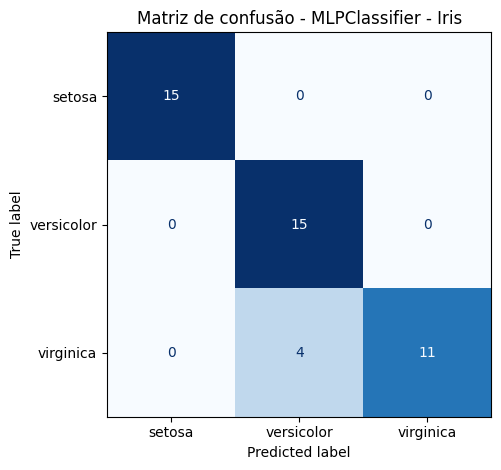

In [11]:
fig, ax = plt.subplots(figsize=(5.8, 4.8))
ConfusionMatrixDisplay(
    resultado_iris["matriz"],
    display_labels=resultado_iris["dados"].target_names,
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusão - MLPClassifier - Iris")
plt.tight_layout()
plt.show()

## 4. Classificação da base Wine

In [12]:
resultado_wine = avaliar_mlp("Wine", load_wine)


Wine
Base                      Wine
Amostras de treino         124
Amostras de teste           54
Acurácia              0.962963
Precisão macro        0.961905
Revocação macro       0.961905

Relatório por classe
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       0.95      0.95      0.95        21
     class_2       0.93      0.93      0.93        15

    accuracy                           0.96        54
   macro avg       0.96      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



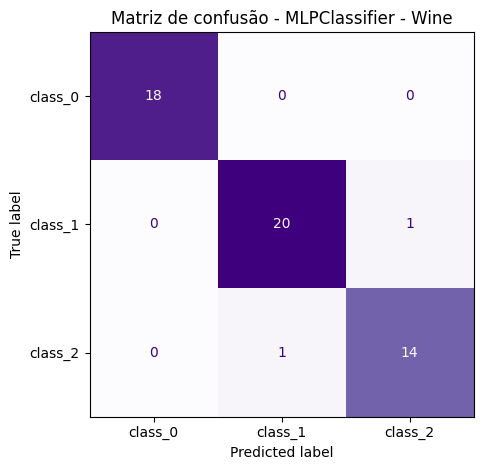

In [13]:
fig, ax = plt.subplots(figsize=(5.8, 4.8))
ConfusionMatrixDisplay(
    resultado_wine["matriz"],
    display_labels=resultado_wine["dados"].target_names,
).plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title("Matriz de confusão - MLPClassifier - Wine")
plt.tight_layout()
plt.show()

## 5. Resumo das métricas do MLPClassifier

In [14]:
resumo_mlp = pd.DataFrame([
    resultado_iris["metricas"],
    resultado_wine["metricas"],
]).set_index("Base")

colunas_metricas = ["Acurácia", "Precisão macro", "Revocação macro"]
display(resumo_mlp.style.format({coluna: "{:.4f}" for coluna in colunas_metricas}))

,Amostras de treino,Amostras de teste,Acurácia,Precisão macro,Revocação macro
Base,,,,,
Iris,105,45,0.9111,0.9298,0.9111
Wine,124,54,0.9630,0.9619,0.9619


## 6. Comparação com o KNN do Trabalho Prático 01

O TP01 obteve no Iris, com `k=5`, **0,9778 de acurácia**, **0,9792 de precisão macro** e **0,9778 de revocação macro**. Esses valores podem ser comparados diretamente com o MLP porque os dois experimentos usam a mesma divisão estratificada e a mesma semente.

,KNN TP01 (k=5),MLPClassifier,Diferença MLP - KNN
Acurácia,0.9778,0.9111,-0.0667
Precisão macro,0.9792,0.9298,-0.0493
Revocação macro,0.9778,0.9111,-0.0667


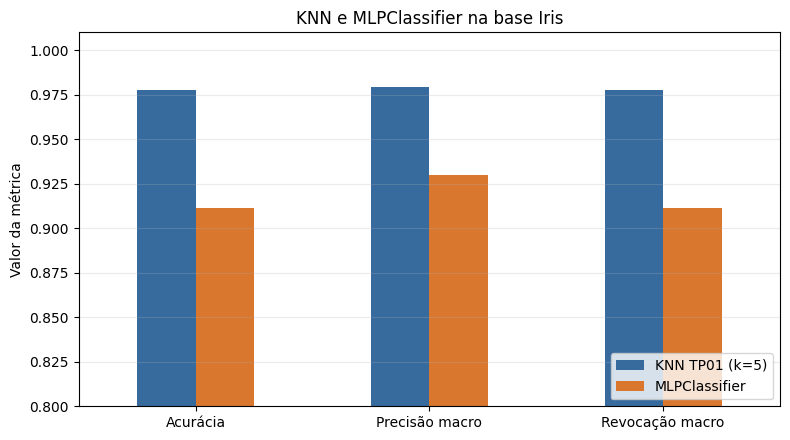

In [15]:
knn_tp01 = {
    "Acurácia": 0.977778,
    "Precisão macro": 0.979167,
    "Revocação macro": 0.977778,
}

comparacao_iris = pd.DataFrame({
    "KNN TP01 (k=5)": knn_tp01,
    "MLPClassifier": {
        metrica: resultado_iris["metricas"][metrica]
        for metrica in knn_tp01
    },
})
comparacao_iris["Diferença MLP - KNN"] = (
    comparacao_iris["MLPClassifier"] - comparacao_iris["KNN TP01 (k=5)"]
)
display(comparacao_iris.style.format("{:.4f}"))

ax = comparacao_iris[["KNN TP01 (k=5)", "MLPClassifier"]].plot(
    kind="bar",
    figsize=(8, 4.5),
    color=["#376B9E", "#D9772E"],
    ylim=(0.80, 1.01),
    rot=0,
)
ax.set_title("KNN e MLPClassifier na base Iris")
ax.set_ylabel("Valor da métrica")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Análise e conclusão

O KNN é um método baseado em distância que praticamente não possui fase de treinamento, mas precisa comparar cada nova amostra com exemplos armazenados. O MLP aprende pesos durante o treinamento e exige padronização e escolha de hiperparâmetros, porém realiza previsões por operações matriciais após o ajuste.

No Iris, a comparação numérica acima mostra se a maior complexidade do MLP trouxe ganho real sobre o KNN do TP01. Como a base é pequena e bem separada, diferenças de uma ou duas amostras alteram vários pontos percentuais e não justificam, isoladamente, afirmar superioridade geral de um algoritmo. No Wine, o mesmo pipeline testa a capacidade do MLP em um problema com mais atributos e escalas distintas.

As matrizes de confusão devem orientar a interpretação: elas mostram quais classes concentram os erros, enquanto precisão e revocação macro atribuem o mesmo peso a cada classe. Para uso prático, a escolha entre KNN e MLP deve considerar também custo de treinamento, custo de predição, necessidade de padronização e estabilidade em novas divisões dos dados.

## 8. Resumo pronto para o relatório após a execução

In [16]:
mlp_iris = resultado_iris["metricas"]
mlp_wine = resultado_wine["metricas"]
print(
    f"Iris - MLP: acurácia {mlp_iris['Acurácia']:.4f}, "
    f"precisão macro {mlp_iris['Precisão macro']:.4f}, "
    f"revocação macro {mlp_iris['Revocação macro']:.4f}."
)
print(
    f"Wine - MLP: acurácia {mlp_wine['Acurácia']:.4f}, "
    f"precisão macro {mlp_wine['Precisão macro']:.4f}, "
    f"revocação macro {mlp_wine['Revocação macro']:.4f}."
)
print(
    f"Iris - diferença de acurácia MLP - KNN: "
    f"{mlp_iris['Acurácia'] - knn_tp01['Acurácia']:+.4f}."
)

Iris - MLP: acurácia 0.9111, precisão macro 0.9298, revocação macro 0.9111.
Wine - MLP: acurácia 0.9630, precisão macro 0.9619, revocação macro 0.9619.
Iris - diferença de acurácia MLP - KNN: -0.0667.
